# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

In [1]:
## install finrl library
# !sudo apt install swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

In [553]:
## We also need to install quantstats, because the environment uses it to plot graphs
# !pip install quantstats

In [89]:
## Hide matplotlib warnings
# import warnings
# warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

#### Import the necessary code libraries

In [90]:
import pandas as pd
import yfinance as yf
from datetime import datetime
class YahooRealtimeDownloader:
    """
    Provides methods for retrieving near-real-time (1-minute) stock data
    from Yahoo Finance API, returning only the last available bar or
    "one minute behind" the latest bar.
    """

    def __init__(self, ticker_list: list):
        """
        Parameters
        ----------
        ticker_list: list
            a list of stock tickers
        """
        self.ticker_list = ticker_list

    def fetch_data(self, proxy=None, pick_second_to_last=True) -> pd.DataFrame:
        """
        Fetches near-real-time 1-minute data from Yahoo API for the current day.
        """
        import datetime
        data_df = pd.DataFrame()
        num_failures = 0

        # 按照 1 分钟周期下载当日数据
        for tic in self.ticker_list:
            temp_df = yf.download(
                tickers=tic,
                period='1d',
                interval='1m',
                proxy=proxy,
                progress=False
            )

            temp_df["tic"] = tic

            if len(temp_df) > 0:
                # 如果您想获取倒数第二条数据
                if pick_second_to_last and len(temp_df) > 1:
                    temp_df = temp_df.iloc[[-2]]  # 取倒数第二行
                else:
                    temp_df = temp_df.iloc[[-1]]

                data_df = pd.concat([data_df, temp_df], axis=0)
            else:
                num_failures += 1

        if num_failures == len(self.ticker_list):
            raise ValueError("No data is fetched. Possibly all tickers returned empty for today.")

        # reset the index
        data_df = data_df.reset_index()

        # rename columns
        try:
            data_df.columns = [
                "date",
                "open",
                "high",
                "low",
                "close",
                "adjcp",
                "volume",
                "tic",
            ]
            data_df["close"] = data_df["adjcp"]
            data_df = data_df.drop(labels="adjcp", axis=1)
        except ValueError:
            print("Columns might not match the expected format; please check yfinance returned columns.")

        # 将日期列转换为 datetime
        data_df["date"] = pd.to_datetime(data_df["date"])
        
        # 获取本地当前日期，例如 2023-10-10
        today = datetime.date.today()

        # 如果行里的 date 不是当天，就改为当天；去掉时分秒，保留 YYYY-MM-DD
        def fix_date(dt):
            if dt.date() != today:
                return today.strftime('%Y-%m-%d')
            else:
                return dt.strftime('%Y-%m-%d')

        data_df["date"] = data_df["date"].apply(fix_date)

        # 再创建 day 列，这里仅保留日期而无时分秒，所以先转回 datetime
        data_df["date"] = pd.to_datetime(data_df["date"])
        data_df["day"] = data_df["date"].dt.dayofweek
        data_df["date"] = data_df["date"].dt.strftime("%Y-%m-%d")

        data_df = data_df.dropna().reset_index(drop=True)

        data_df = data_df.sort_values(by=["date", "tic"]).reset_index(drop=True)

        print("Shape of realtime DataFrame: ", data_df.shape)
        print(data_df)
        return data_df

In [91]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [92]:
market = "us"
if market.lower() == "us":
    TOP_BRL = [
        'BILI', 'DUO', 'NIO', 'JD', 'YINN', 'YANG', 'FUTU','XHG'
    ]
elif market.lower() == "hk":
    TOP_BRL = [
         '1812.hk', '3900.hk', '2777.hk', '1810.hk', '2878.HK','0029.hk'
    ]
elif market.lower() == "ch":
    TOP_BRL = [
         '603063.ss', '603319.ss', '000657.sz','002640.sz','002664.sz','300182.sz','688200.SS','002850.SZ'
    ]

    # TOP_BRL = [
    # '000063.SZ',
    # '002068.SZ',
    # '002138.SZ',
    # '002779.SZ',
    # '002850.SZ',
    # '300408.SZ',
    # '300442.SZ',
    # '300657.SZ',
    # '300673.SZ',
    # '300909.SZ',
    # '300913.SZ',
    # '601111.SS',
    # '601689.SS',
    # '603063.SS',
    # '603236.SS',
    # '603305.SS',
    # '603556.SS',
    # '603667.SS',
    # '688088.SS',
    # '688160.SS',
    # '688200.SS']
else:
    raise ValueError("market 变量必须为 'us' 或 'hk'")

print("当前选择的市场:", market)
print("股票列表:", TOP_BRL)
# '9988.hk',,'1797.hk''1918.hk', '3319.hk',

当前选择的市场: us
股票列表: ['BILI', 'DUO', 'NIO', 'JD', 'YINN', 'YANG', 'FUTU', 'XHG']


In [95]:
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2020-01-01',
                                end_date = '2025-01-29',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

8


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (10184, 8)


,date,open,high,low,close,volume,tic,day
0,2020-01-02,19.469999,21.889999,19.299999,20.950001,12629400,BILI,3
1,2020-01-02,3366.000000,3722.850098,3366.000000,3690.000000,48,DUO,3
2,2020-01-02,10.470000,10.880000,10.433000,10.680000,242700,FUTU,3
3,2020-01-02,35.959999,37.759998,35.900002,35.245708,22688700,JD,3
4,2020-01-02,4.100000,4.100000,3.610000,3.720000,103740100,NIO,3
...,...,...,...,...,...,...,...,...
10179,2025-01-24,39.805000,40.779999,39.575001,40.720001,11746300,JD,4
10180,2025-01-24,4.190000,4.350000,4.140000,4.290000,40307300,NIO,4
10181,2025-01-24,0.928000,0.942000,0.820000,0.912000,518300,XHG,4
10182,2025-01-24,65.800003,66.339996,63.360001,63.759998,1066300,YANG,4


In [78]:
realtime_df = YahooRealtimeDownloader(ticker_list = TOP_BRL).fetch_data()
# 假设这两个 DataFrame 的列名相同 
portfolio_raw_df = pd.concat([portfolio_raw_df, realtime_df], ignore_index=True)

# 对合并后的数据，根据日期和股票标的排序，并重新索引
portfolio_raw_df = portfolio_raw_df.sort_values(["date", "tic"]).reset_index(drop=True)

# 检查合并后的数据
print(portfolio_raw_df.head())
print(portfolio_raw_df.tail())

Shape of realtime DataFrame:  (8, 8)
         date       open       high        low      close   volume   tic  day
0  2025-01-24  16.405001  16.420000  16.400000  16.420000    56599  BILI    4
1  2025-01-24   0.591000   0.591000   0.591000   0.591000     1473   DUO    4
2  2025-01-24  92.400002  92.434998  92.360001  92.379997    19966  FUTU    4
3  2025-01-24  38.689999  38.709999  38.689999  38.695000   118720    JD    4
4  2025-01-24   4.125000   4.140000   4.120000   4.135000  1101009   NIO    4
5  2025-01-24   0.936300   0.936300   0.926300   0.926300     3257   XHG    4
6  2025-01-24  68.699997  68.709999  68.610001  68.610001     4217  YANG    4
7  2025-01-24  27.721399  27.770000  27.721399  27.769800    34902  YINN    4
         date         open         high          low        close     volume  \
0  2020-01-02    19.469999    21.889999    19.299999    20.950001   12629400   
1  2020-01-02  3366.000000  3722.850098  3366.000000  3690.000000         48   
2  2020-01-02    10.4

In [79]:
from finrl.config import INDICATORS
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False,
    user_defined_feature=False
)
processed = fe.preprocess_data(portfolio_raw_df)
logging.info("数据预处理完成。")

Successfully added technical indicators


In [ ]:
# from feature.ch_feature_engineer import ChFeatureEngineer
# ch_fe = ChFeatureEngineer()
# portfolio_processed = ch_fe.preprocess_data(processed)
# logging.info("自定义特征工程完成。")

In [105]:
import datetime
import pandas as pd
# 节假日日期字典（已修正）
holidays = {
    '春节': {
        '2018': '2018-02-15',
        '2019': '2019-02-05',
        '2020': '2020-01-24',
        '2021': '2021-02-11',
        '2022': '2022-01-31',
        '2023': '2023-01-21',
        '2024': '2024-02-10',
        '2025': '2025-01-28'
    },
    # '五一': {
    #     '2018': '2018-05-01',
    #     '2019': '2019-05-01',
    #     '2020': '2020-05-01',
    #     '2021': '2021-05-01',
    #     '2022': '2022-05-01',
    #     '2023': '2023-05-01',
    #     '2024': '2024-05-01',
    #     '2025': '2025-05-01'
    # },
    # '国庆': {
    #     '2018': '2018-10-01',
    #     '2019': '2019-10-01',
    #     '2020': '2020-10-01',
    #     '2021': '2021-10-01',
    #     '2022': '2022-10-01',
    #     '2023': '2023-10-01',
    #     '2024': '2024-10-01',
    #     '2025': '2025-10-01'
    # }
}

# 只选择2019年及以后的日期
selected_holidays = {}
for holiday, years in holidays.items():
    selected_holidays[holiday] = {}
    for year, date_str in years.items():
        if int(year) >= 2019:
            selected_holidays[holiday][year] = date_str

# 生成节假日前后18天的日期范围
date_ranges = []
yesterday = datetime.date.today() - datetime.timedelta(days=0)
for holiday, years in selected_holidays.items():
    for year, date_str in years.items():
        holiday_date = datetime.datetime.strptime(date_str, '%Y-%m-%d').date()
        start_date = holiday_date - datetime.timedelta(days=8)
        end_date = holiday_date + datetime.timedelta(days=0)
        today = datetime.date.today()
        if end_date > yesterday:
            end_date = yesterday
        date_ranges.append((start_date, end_date))


# 找到所有日期范围的最小开始日期和最大结束日期
overall_start_date = min([start for start, end in date_ranges])
overall_end_date = max([end for start, end in date_ranges])

print(f"\n总体下载日期范围：{overall_start_date} 至 {overall_end_date}")



# 下载数据
# logging.info("开始下载股票数据...")
# portfolio_raw_df = YahooDownloader(
#     start_date=str(overall_start_date),
#     end_date=str(overall_end_date),
#     ticker_list=TOP_BRL
# ).fetch_data()
# logging.info("股票数据下载完成。")

# 确保 'date' 列为 datetime 类型
portfolio_raw_df['date'] = pd.to_datetime(portfolio_raw_df['date']).dt.date

# 初始化一个空的DataFrame来存储筛选后的数据
filtered_df = pd.DataFrame()

# 遍历每个日期范围，并筛选数据
for start, end in date_ranges:
    print(start,end)
    mask = (portfolio_raw_df['date'] >= start) & (portfolio_raw_df['date'] <= end)
    temp_df = portfolio_raw_df.loc[mask]
    # print(temp_df.tail())
    filtered_df = pd.concat([filtered_df, temp_df], ignore_index=True)
    print(filtered_df.tail())
filtered_df['date'] = filtered_df['date'].astype(str)
filtered_df = filtered_df.sort_values(['date', 'tic']).reset_index(drop=True)
# 删除重复的数据（如果有重叠的日期范围）
# filtered_df.drop_duplicates(subset=['date', 'tic'], inplace=True)

print("\n筛选后的数据示例：")
print(filtered_df.tail())

print(f"\n筛选后的数据总行数：{len(filtered_df)}")


总体下载日期范围：2019-01-28 至 2025-01-26
2019-01-28 2019-02-05
Empty DataFrame
Columns: [date, open, high, low, close, volume, tic, day]
Index: []
2020-01-16 2020-01-24
          date          open          high           low         close  \
43  2020-01-24     40.759998     40.970001     39.189999     36.945873   
44  2020-01-24      5.000000      5.060000      4.510000      4.660000   
45  2020-01-24  48136.000000  48136.000000  48136.000000  48136.000000   
46  2020-01-24    810.200012    849.599976    808.200012    792.029419   
47  2020-01-24    410.799988    411.799988    390.600006    367.073303   

      volume   tic  day  
43  14322200    JD    4  
44  65538000   NIO    4  
45         0   XHG    4  
46     64100  YANG    4  
47    150140  YINN    4  
2021-02-03 2021-02-11
           date          open          high           low         close  \
99   2021-02-11     99.949997     99.949997     98.129997     92.481453   
100  2021-02-11     61.689999     63.060001     59.810001     60.

In [106]:
filtered_df.groupby("tic").count()

,date,open,high,low,close,volume,day
tic,,,,,,,
BILI,34,34,34,34,34,34,34
DUO,34,34,34,34,34,34,34
FUTU,34,34,34,34,34,34,34
JD,34,34,34,34,34,34,34
NIO,34,34,34,34,34,34,34
XHG,34,34,34,34,34,34,34
YANG,34,34,34,34,34,34,34
YINN,34,34,34,34,34,34,34


### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

In [107]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(filtered_df)
portfolio_norm_df

/Users/pu17/Documents/stock/FinRL/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.22269978 0.48106041 0.49720157 0.32226852 0.28256507 0.29574361
 0.45309068 0.67924198 0.4883429  0.32787998 0.41892572 0.89842456
 0.35251494 0.69383615 0.26084894 0.38176896 0.48818967 0.49021096
 0.46321904 0.62066827 0.46061398 0.38253515 0.57918433 0.47193905
 0.41089893 0.41337994 1.         0.65357083 0.40722849 0.32003561
 0.30423012 0.35622916 0.34100014 0.53207434]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/Documents/stock/FinRL/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.75 1.   0.25 0.5  0.75 1.   0.5  0.75 1.  

,date,open,high,low,close,volume,tic,day
0,2020-01-16,0.150719,0.149689,0.153380,0.146895,0.222700,BILI,0.75
1,2020-01-16,1.000000,1.000000,0.961120,1.000000,0.000008,DUO,0.75
2,2020-01-16,0.063956,0.059339,0.072793,0.072682,0.024304,FUTU,0.75
3,2020-01-16,0.402001,0.400816,0.401559,0.399596,0.426310,JD,0.75
4,2020-01-16,0.063789,0.068111,0.064810,0.069542,0.472845,NIO,0.75
...,...,...,...,...,...,...,...,...
267,2025-01-24,0.398249,0.405892,0.403292,0.440305,0.584163,JD,1.00
268,2025-01-24,0.066986,0.067337,0.068623,0.068269,0.194597,NIO,1.00
269,2025-01-24,0.000019,0.000015,0.000017,0.000018,0.434670,XHG,1.00
270,2025-01-24,0.079854,0.078084,0.078396,0.080502,0.790414,YANG,1.00


In [100]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low",'volume']]

df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2019-01-01") & (df_portfolio["date"] <= "2025-01-24")]

df_portfolio_2025 = df_portfolio[(df_portfolio["date"] >= "2024-09-01") & (df_portfolio["date"] <= "2025-01-29")]

unique_dates = df_portfolio_2025['date'].drop_duplicates().sort_values().reset_index(drop=True)
print(unique_dates)

0     2025-01-08
1     2025-01-10
2     2025-01-13
3     2025-01-14
4     2025-01-15
5     2025-01-16
6     2025-01-17
7     2025-01-21
8     2025-01-22
9     2025-01-23
10    2025-01-24
Name: date, dtype: object


### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [108]:
features=["close", "high", "low",'volume']
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=4,
        features=features,
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [109]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.01,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 4,
    "initial_features":len(features)
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

model_name = "27_ORIGINAL"
file_path = f"policy_EIIE_US_{model_name}.pt"
import os
import torch

# if market.lower() == "us":
#     if os.path.isfile(file_path):
#         model.train_policy.load_state_dict(torch.load(file_path))
#         print(f"成功加载模型参数：{file_path}")
#     else:
#         print(f"未找到模型文件: {file_path}，请确认路径或先进行保存。")
# elif market.lower() == "hk":
#     if os.path.isfile(file_path):
#         model.train_policy.load_state_dict(torch.load("policy_EIIE_HK.pt"))
#         print("成功加载模型参数：policy_EIIE_HK.pt")
#     else:
#         print(f"未找到模型文件: {file_path}，请确认路径或先进行保存。")
# elif market.lower() == "ch":
#     model.train_policy.load_state_dict(torch.load("policy_EIIE_CH3.pt"))
#     print("成功加载模型参数：policy_EIIE_CH3.pt")
# else:
#     raise ValueError("market 变量必须为 'us' 或 'hk'")

### Train Model

In [112]:
DRLAgent.train_model(model, episodes=40)

if market.lower() == "us":  
    torch.save(model.train_policy.state_dict(), "policy_EIIE_US_{}.pt".format(model_name))

elif market.lower() == "hk":
    torch.save(model.train_policy.state_dict(), "policy_EIIE_HK.pt")
elif market.lower() == "ch":
    torch.save(model.train_policy.state_dict(), "policy_EIIE_CH3.pt")
else:
    raise ValueError("market 变量必须为 'us' 或 'hk'")

  0%|          | 0/40 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 1710365.125
Final accumulative portfolio value: 17.10365125
Maximum DrawDown: -0.41706278233958793
Sharpe ratio: 1.901081432643271


  2%|▎         | 1/40 [00:02<01:24,  2.18s/it]

Initial portfolio value:100000
Final portfolio value: 1857852.25
Final accumulative portfolio value: 18.5785225
Maximum DrawDown: -0.41157608163057324
Sharpe ratio: 1.9129556859200036


  5%|▌         | 2/40 [00:03<00:54,  1.43s/it]

...

 95%|█████████▌| 38/40 [00:29<00:01,  1.42it/s]

Initial portfolio value:100000
Final portfolio value: 5739893.0
Final accumulative portfolio value: 57.39893
Maximum DrawDown: -0.17615963669583656
Sharpe ratio: 2.096815283132515


 98%|█████████▊| 39/40 [00:30<00:00,  1.42it/s]

Initial portfolio value:100000
Final portfolio value: 5825495.5
Final accumulative portfolio value: 58.254955
Maximum DrawDown: -0.17600795169668748
Sharpe ratio: 2.0993208758790938


100%|██████████| 40/40 [00:31<00:00,  1.28it/s]


### Save Model

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [111]:
policy = EIIE(time_window=4, device=device,initial_features=len(features))
policy.load_state_dict(torch.load("policy_EIIE_CH3.pt"))
if market.lower() == "us":
    policy.load_state_dict(torch.load("policy_EIIE_US.pt"))
elif market.lower() == "hk":
    policy.load_state_dict(torch.load("policy_EIIE_HK.pt"))
elif market.lower() == "ch":
    policy.load_state_dict(torch.load("policy_EIIE_CH3.pt"))
else:
    raise ValueError("market 变量必须为 'us' 或 'hk'")

environment_2025 = PortfolioOptimizationEnv(
    df_portfolio_2025,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=4,
    features=features,
    normalize_df=None
)
# df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
#     model=model, 
#     environment = environment_2025)
DRLAgent.DRL_validation(model, environment_2025, policy=policy)
# environment_2021 = PortfolioOptimizationEnv(
#     df_portfolio_2021,
#     initial_amount=100000,
#     comission_fee_pct=0.0025,
#     time_window=50,
#     features=["close", "high", "low"],
#     normalize_df=None
# )

# environment_2022 = PortfolioOptimizationEnv(
#     df_portfolio_2022,
#     initial_amount=100000,
#     comission_fee_pct=0.0025,
#     time_window=50,
#     features=["close", "high", "low"],
#     normalize_df=None
# )

# for i, action in enumerate(environment_2025._actions_memory):
#     if not np.isnan(action).all():  # 如果 action 中不全是 NaN
#         if i < len(unique_dates):
#             current_date = unique_dates.iloc[i]
#         else:
#             current_date = '未知日期'  # 处理索引超出范围的情况
#         print(f"Action on {current_date} at step {i}: {action}")

# columns = ["date", "cash"] + TOP_BRL  
# results = []
unique_dates = df_portfolio_2025['date'].drop_duplicates().sort_values().reset_index(drop=True)

columns = ["date", "cash"] + TOP_BRL  
results = []

shift_value = 3  # 想统一日期往后移 4 格
actions = environment_2025._actions_memory

for i, action in enumerate(actions):
    # 如果 action 全是 NaN，我们跳过
    if np.isnan(action).all():
        continue
    
    shifted_index = i + shift_value
    if shifted_index < len(unique_dates):
        current_date = unique_dates.iloc[shifted_index]
    else:
        current_date = '未知日期'
    
    # 将 action 转成百分比字符串，比如 0.123 -> "12.30%"
    action_in_percent = [f"{x*100:.2f}%" for x in action]
    
    # 构建一行 [日期, 第一列现金比例, 后面的列是各股票比例]
    row = [current_date] + action_in_percent
    results.append(row)

# 创建 DataFrame
df_action_percent = pd.DataFrame(results, columns=columns)
print("日期统一往后移 3 格后的 DataFrame：")
print(df_action_percent.tail(10))



Initial portfolio value:100000
Final portfolio value: 92635.125
Final accumulative portfolio value: 0.92635125
Maximum DrawDown: -0.11161399531535487
Sharpe ratio: -4.0795268411911065
日期统一往后移 3 格后的 DataFrame：
         date     cash   BILI      DUO    NIO     JD   YINN   YANG    FUTU  \
0  2025-01-14  100.00%  0.00%    0.00%  0.00%  0.00%  0.00%  0.00%   0.00%   
1  2025-01-15    0.00%  0.00%  100.00%  0.00%  0.00%  0.00%  0.00%   0.00%   
2  2025-01-16    0.00%  0.00%  100.00%  0.00%  0.00%  0.00%  0.00%   0.00%   
3  2025-01-17    0.00%  0.00%  100.00%  0.00%  0.00%  0.00%  0.00%   0.00%   
4  2025-01-21    0.00%  0.00%  100.00%  0.00%  0.00%  0.00%  0.00%   0.00%   
5  2025-01-22    0.00%  0.00%   99.99%  0.00%  0.00%  0.00%  0.00%   0.00%   
6  2025-01-23    0.00%  0.00%   34.32%  0.00%  0.02%  0.00%  0.00%  65.66%   
7  2025-01-24    0.00%  0.00%    0.10%  0.00%  0.00%  0.00%  0.00%  99.90%   

     XHG  
0  0.00%  
1  0.00%  
2  0.00%  
3  0.00%  
4  0.00%  
5  0.00%  
6  0.00%  


In [681]:
# unique_dates = df_portfolio['date'].drop_duplicates().sort_values().reset_index(drop=True)


### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [88]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2025": {},

}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=50, device=device)
policy.load_state_dict(torch.load("policy_EIIE_US.pt"))

# 2020
DRLAgent.DRL_validation(model, environment_2025, policy=policy)
EIIE_results["2025"]["value"] = environment_2025._asset_memory["final"]

# # 2021
# DRLAgent.DRL_validation(model, environment_2021, policy=policy)
# EIIE_results["2021"]["value"] = environment_2021._asset_memory["final"]

# # 2022
# DRLAgent.DRL_validation(model, environment_2022, policy=policy)
# EIIE_results["2022"]["value"] = environment_2022._asset_memory["final"]

RuntimeError: Error(s) in loading state_dict for EIIE:
	size mismatch for sequential.0.weight: copying a param with shape torch.Size([2, 4, 1, 3]) from checkpoint, the shape in current model is torch.Size([2, 3, 1, 3]).
	size mismatch for sequential.2.weight: copying a param with shape torch.Size([20, 2, 1, 2]) from checkpoint, the shape in current model is torch.Size([20, 2, 1, 48]).

In [185]:
# unique_dates = df_portfolio['date'].drop_duplicates().sort_values().reset_index(drop=True)
unique_dates = df_portfolio_2025['date'].drop_duplicates().sort_values().reset_index(drop=True)
for i, action in enumerate(environment_2025._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        if i < len(unique_dates):
            current_date = unique_dates.iloc[i]
        else:
            current_date = '未知日期'  # 处理索引超出范围的情况
        print(f"Action on {current_date} at step {i}: {action}")

Action on 2024-09-09 at step 0: [1. 0. 0. 0. 0. 0. 0.]
Action on 2024-09-10 at step 1: [9.9999988e-01 1.4793630e-10 4.8313072e-11 2.3062806e-15 2.6634750e-18
 1.3281576e-07 2.3748823e-08]
Action on 2024-09-11 at step 2: [9.9999988e-01 1.3734557e-10 5.2449049e-11 1.4694491e-15 2.3904856e-18
 8.8959673e-08 1.9711914e-08]
Action on 2024-09-12 at step 3: [1.0000000e+00 1.2335671e-10 5.5279763e-11 7.6958655e-16 1.9648228e-18
 5.1419473e-08 1.4674211e-08]
Action on 2024-09-13 at step 4: [1.0000000e+00 1.0960885e-10 5.7427396e-11 3.8348231e-16 1.5733505e-18
 2.8679301e-08 1.0589637e-08]
Action on 2024-09-16 at step 5: [1.0000000e+00 9.7143071e-11 5.9283120e-11 1.8687724e-16 1.2384563e-18
 1.5647753e-08 7.4410544e-09]
Action on 2024-09-17 at step 6: [1.0000000e+00 8.7069352e-11 6.2441802e-11 9.7090166e-17 1.0128829e-18
 8.6165093e-09 5.2546434e-09]
Action on 2024-09-19 at step 7: [1.0000000e+00 7.8642752e-11 6.7394874e-11 5.2910995e-17 8.5227267e-19
 4.7110764e-09 3.6790180e-09]
Action on 2024

In [177]:
filtered_df.tail()

,date,open,high,low,close,volume,tic,day
1897,2025-01-14,1.12,1.15,1.12,1.15,1755000,1812.hk,1
1898,2025-01-14,1.49,1.57,1.45,1.54,396861547,1918.hk,1
1899,2025-01-14,1.22,1.27,1.22,1.27,12177163,2777.hk,1
1900,2025-01-14,2.67,2.72,2.66,2.69,2425500,3319.hk,1
1901,2025-01-14,8.42,8.87,8.42,8.77,4056796,3900.hk,1


### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [54]:
UBAH_results = {
    "train": {},
    "2025": {},
    # "2021": {},
    # "2022": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# 2020
terminated = False
environment_2025.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2025.step(action)
UBAH_results["2025"]["value"] = environment_2025._asset_memory["final"]

# # 2021
# terminated = False
# environment_2021.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2021.step(action)
# UBAH_results["2021"]["value"] = environment_2021._asset_memory["final"]

# # 2022
# terminated = False
# environment_2022.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2022.step(action)
# UBAH_results["2022"]["value"] = environment_2022._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 71258.3125
Final accumulative portfolio value: 0.712583125
Maximum DrawDown: -0.6791984908065596
Sharpe ratio: 0.07982901637304428
Initial portfolio value:100000
Final portfolio value: 106720.71875
Final accumulative portfolio value: 1.0672071875
Maximum DrawDown: -0.46812625377421013
Sharpe ratio: 0.4403333031023637


### Plot graphics

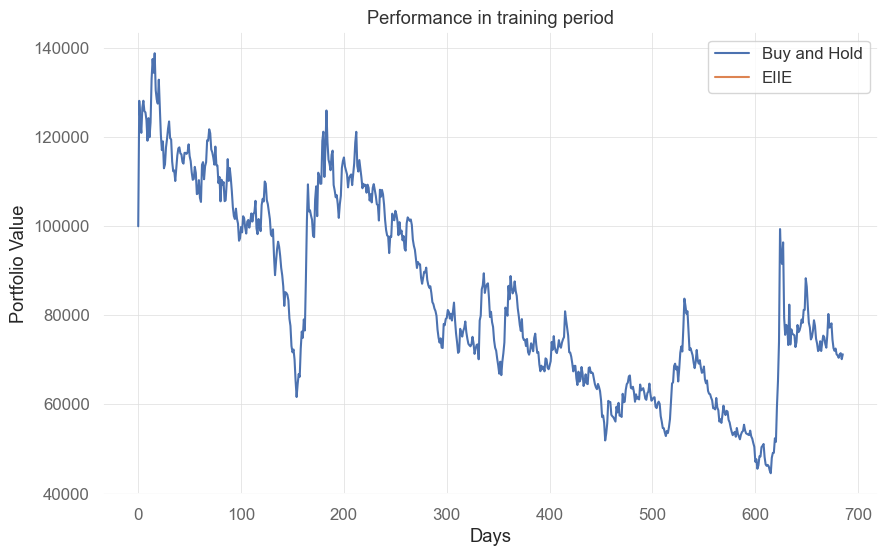

In [55]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

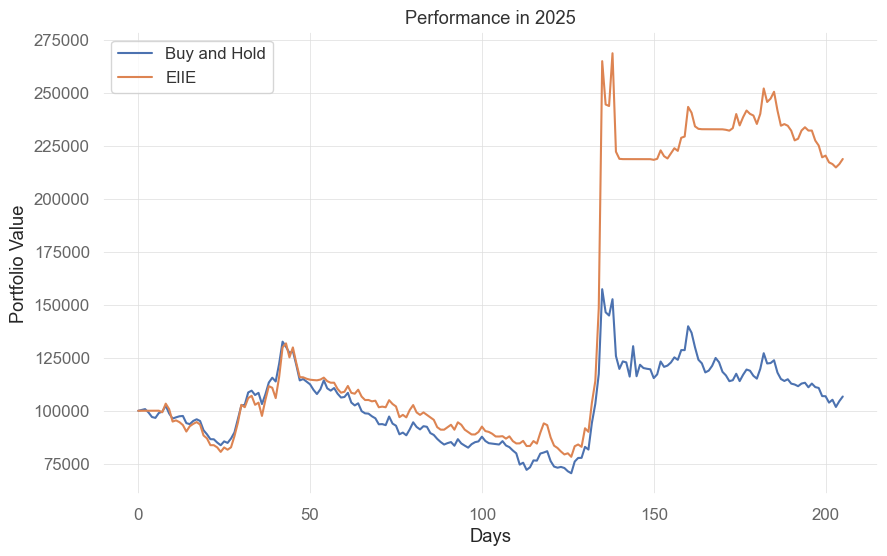

In [56]:
plt.plot(UBAH_results["2025"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2025"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2025")
plt.legend()

plt.show()

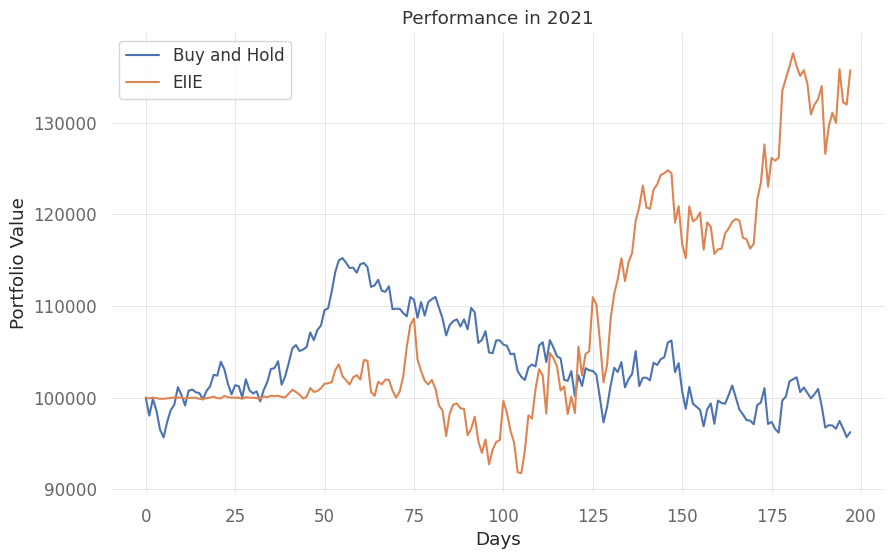

In [59]:
plt.plot(UBAH_results["2021"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2021"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2021")
plt.legend()

plt.show()

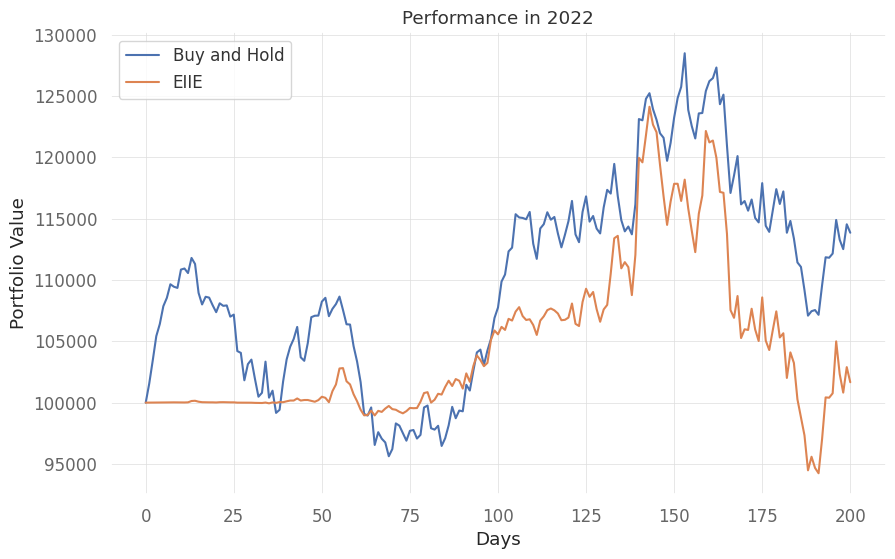

In [60]:
plt.plot(UBAH_results["2022"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2022"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2022")
plt.legend()

plt.show()

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.